# Prediksi Loan Approval — KOM1338 Data Mining
## Lampiran Kode Lengkap (*Complete Code Appendix*)

| Atribut | Keterangan |
|---|---|
| **Kompetisi** | KOM1338 Data Mining — Prediksi *Loan Approval* |
| **Metrik Evaluasi** | AUC-ROC (*Area Under the ROC Curve*) |
| **Jenis Masalah** | *Binary Classification* (Supervised Learning) |
| **Pendekatan** | Ensemble tiga model *gradient boosting* + *rank-blend* |
| **OOF AUC Terbaik** | **0.9325** (5-*fold* StratifiedKFold) |

---

### Ringkasan Metodologi

Notebook ini mendokumentasikan seluruh *pipeline* machine learning secara lengkap —
dari eksplorasi data hingga *submission*. Tiga model *gradient boosting*
(LightGBM, XGBoost, CatBoost) dibangun secara terpisah, masing-masing di-*tune*
menggunakan Optuna (*Tree-structured Parzen Estimator*), lalu digabung melalui
**rank-blend ensemble**. Evaluasi menggunakan **OOF (*out-of-fold*) prediction**
sehingga estimasi AUC bebas dari *data leakage*.

### Daftar Isi
1. [Setup & Konfigurasi Global](#1-setup--konfigurasi-global)
2. [Muat dan Periksa Data](#2-muat-dan-periksa-data)
3. [Analisis Data Eksploratif (EDA)](#3-analisis-data-eksploratif-eda)
   - 3.1 Distribusi Target & Ketidakseimbangan Kelas
   - 3.2 Distribusi Fitur Numerik
   - 3.3 Analisis Fitur Kategorikal & Default Rate
   - 3.4 Matriks Korelasi
4. [Rekayasa Fitur (*Feature Engineering*)](#4-rekayasa-fitur-feature-engineering)
5. [Preprocessing & Encoding](#5-preprocessing--encoding)
6. [Fungsi *Cross-Validation* (OOF)](#6-fungsi-cross-validation-oof)
7. [*Hyperparameter Tuning* dengan Optuna](#7-hyperparameter-tuning-dengan-optuna)
8. [Pelatihan Model & Prediksi OOF](#8-pelatihan-model--prediksi-oof)
9. [Ensemble: *Rank-Blend*](#9-ensemble-rank-blend)
10. [Analisis *Feature Importance*](#10-analisis-feature-importance)
11. [Uji Signifikansi (*Wilcoxon Signed-Rank Test*)](#11-uji-signifikansi-wilcoxon-signed-rank-test)
12. [Generasi File Submission](#12-generasi-file-submission)
13. [Kesimpulan & Ringkasan](#13-kesimpulan--ringkasan)

## 1. Setup & Konfigurasi Global

Seluruh *library* yang dibutuhkan di-*import* di satu tempat agar mudah dilacak.
Konfigurasi global (seed, jumlah fold, nama kolom) dipusatkan agar tidak ada
*magic number* tersebar di kode. Penggunaan `SEED = 42` memastikan eksperimen
sepenuhnya dapat direproduksi.

In [1]:
# ── Standard library ────────────────────────────────────────────────────────
import json
import warnings
from itertools import product
from pathlib import Path

# ── Numerical & data ────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ───────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Statistical tests ───────────────────────────────────────────────────────
from scipy.stats import rankdata, wilcoxon

# ── Machine learning ────────────────────────────────────────────────────────
from sklearn.metrics import roc_auc_score, RocCurveDisplay
from sklearn.model_selection import StratifiedKFold, cross_val_score
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier
import optuna

# ── Silence noisy output ────────────────────────────────────────────────────
warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

print("Import selesai.")

Import selesai.


In [2]:
# ── Global constants ────────────────────────────────────────────────────────
SEED      = 42            # reproducibility seed for all random operations
N_SPLITS  = 5             # number of CV folds
TARGET    = "loan_status" # binary target: 1 = default, 0 = paid-off
ID_COL    = "sample_id"   # row identifier (not used as a feature)

# loan_grade has a monotone default rate: A(~5%) → G(~85%)
# Integer encoding preserves this ordinal relationship more naturally
# than one-hot encoding, which would lose the ordering information.
GRADE_MAP = {"A": 1, "B": 2, "C": 3, "D": 4, "E": 5, "F": 6, "G": 7}

# Nominal categoricals: treated with one-hot encoding for LightGBM/XGBoost,
# and with CatBoost's native target-statistics for CatBoost.
CAT_COLS  = ["person_home_ownership", "loan_intent", "cb_person_default_on_file"]

# Directory for saving figures and model artifacts
FIG_DIR   = Path("reports/figures")
MDL_DIR   = Path("models")
FIG_DIR.mkdir(parents=True, exist_ok=True)
MDL_DIR.mkdir(exist_ok=True)

print(f"SEED={SEED} | N_SPLITS={N_SPLITS} | TARGET='{TARGET}'")
print(f"Categorical columns: {CAT_COLS}")

SEED=42 | N_SPLITS=5 | TARGET='loan_status'
Categorical columns: ['person_home_ownership', 'loan_intent', 'cb_person_default_on_file']


## 2. Muat dan Periksa Data

Dataset terdiri dari dua file CSV: `train.csv` (data berlabel) dan `test.csv`
(data yang perlu diprediksi). Setiap baris merepresentasikan satu aplikasi
pinjaman dengan 12 fitur input.

**Deskripsi fitur:**

| Fitur | Tipe | Keterangan |
|---|---|---|
| `person_age` | Numerik | Usia peminjam (tahun) |
| `person_income` | Numerik | Pendapatan tahunan (USD) |
| `person_home_ownership` | Kategorikal | Status kepemilikan rumah (RENT, OWN, MORTGAGE, OTHER) |
| `person_emp_length` | Numerik | Lama bekerja (tahun) |
| `loan_intent` | Kategorikal | Tujuan pinjaman (PERSONAL, EDUCATION, dll.) |
| `loan_grade` | Ordinal | Peringkat kredit (A=terbaik … G=terburuk) |
| `loan_amnt` | Numerik | Jumlah pinjaman (USD) |
| `loan_int_rate` | Numerik | Suku bunga pinjaman (%) |
| `loan_percent_income` | Numerik | Rasio pinjaman terhadap pendapatan |
| `cb_person_default_on_file` | Kategorikal | Riwayat default sebelumnya (Y/N) |
| `cb_person_cred_hist_length` | Numerik | Panjang riwayat kredit (tahun) |
| `loan_status` | **Target** | 1 = default, 0 = lunas *(hanya di train)* |

In [3]:
# Load raw CSVs from project root
train = pd.read_csv("train.csv")
test  = pd.read_csv("test.csv")

print(f"Train shape : {train.shape}  (rows × columns)")
print(f"Test shape  : {test.shape}")
print(f"\nClass distribution (TARGET='{TARGET}'):")
vc = train[TARGET].value_counts()
print(f"  0 (lunas)  : {vc[0]:,}  ({vc[0]/len(train):.1%})")
print(f"  1 (default): {vc[1]:,}  ({vc[1]/len(train):.1%})")
print(f"\nImbalance ratio: 1:{vc[0]/vc[1]:.1f}  (kelas negatif vs positif)")

Train shape : (43983, 13)  (rows × columns)


Test shape  : (14662, 12)

Class distribution (TARGET='loan_status'):
  0 (lunas)  : 37,721  (85.8%)
  1 (default): 6,262  (14.2%)

Imbalance ratio: 1:6.0  (kelas negatif vs positif)


In [4]:
# Overview of column types and completeness
info_df = pd.DataFrame({
    "dtype"      : train.dtypes,
    "null_count" : train.isnull().sum(),
    "null_pct"   : (train.isnull().sum() / len(train) * 100).round(2),
    "n_unique"   : train.nunique(),
    "sample"     : train.iloc[0],
})
print("=== Train — Column Info ===")
print(info_df.to_string())

=== Train — Column Info ===
                              dtype  null_count  null_pct  n_unique      sample
sample_id                    object           0       0.0     43983  TR56654936
person_age                    int64           0       0.0        59          30
person_income                 int64           0       0.0      1923       29900
person_home_ownership        object           0       0.0         4        RENT
person_emp_length           float64           0       0.0        36         0.0
loan_intent                  object           0       0.0         6    PERSONAL
loan_grade                   object           0       0.0         7           D
loan_amnt                     int64           0       0.0       343        4700
loan_int_rate               float64           0       0.0      1474       14.58
loan_percent_income         float64           0       0.0        76        0.16
cb_person_default_on_file    object           0       0.0         2           Y
cb_person_cr

In [5]:
# Descriptive statistics for numerical features
print("=== Descriptive Statistics (Train) ===")
display(train.describe().round(2))

=== Descriptive Statistics (Train) ===


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,loan_status
count,43983.00,43983.00,43983.00,43983.00,43983.00,43983.00,43983.00,43983.00
mean,27.56,64004.14,4.76,9224.99,10.68,0.16,5.82,0.14
std,6.20,37517.14,3.97,5566.81,3.04,0.10,4.11,0.35
min,18.00,5100.00,0.00,700.00,4.81,0.00,1.00,0.00
25%,23.00,41900.00,2.00,5100.00,7.80,0.09,3.00,0.00
50%,26.00,57200.00,4.00,8100.00,10.79,0.14,4.00,0.00
75%,30.00,76800.00,7.00,12000.00,12.98,0.21,8.00,0.00
max,100.00,1992500.00,80.00,37100.00,23.20,2.88,31.00,1.00


## 3. Analisis Data Eksploratif (EDA)

EDA bertujuan memahami distribusi data, mengidentifikasi *outlier*, dan menggali
pola yang relevan sebelum membangun model. Insight dari EDA menginformasikan
keputusan rekayasa fitur dan strategi penanganan ketidakseimbangan kelas.

### 3.1 Distribusi Target & Ketidakseimbangan Kelas

Dataset bersifat **tidak seimbang** (*imbalanced*) dengan proporsi kelas positif
(default) sekitar 14.2%. Ini penting karena:
- Metrik seperti *accuracy* menjadi menyesatkan (model yang selalu memprediksi 0
  sudah benar 85.8% waktu).
- Metrik AUC-ROC lebih tepat karena berbasis *ranking*, bukan *threshold*.
- Keputusan apakah menggunakan *class weighting* atau *resampling* harus diuji
  secara empiris (hasil: keduanya menurunkan OOF AUC pada dataset ini).

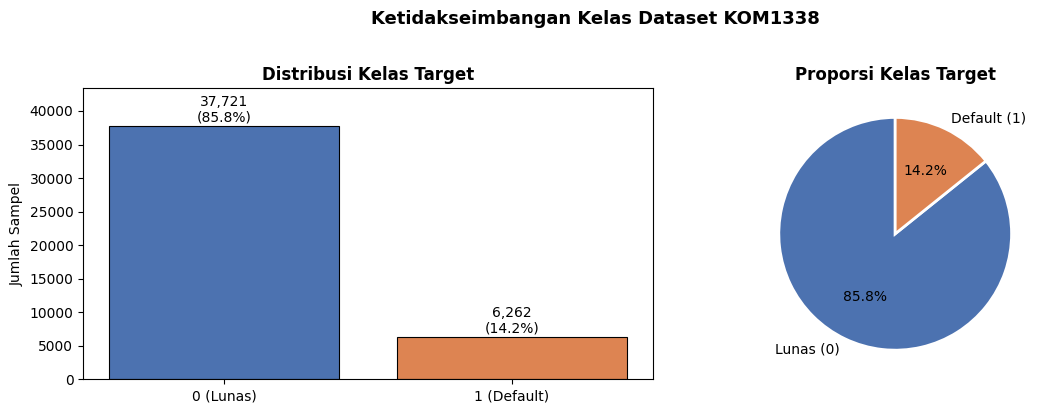


Rasio ketidakseimbangan: 1 positif per 6.0 negatif


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: bar chart of class counts
vc = train[TARGET].value_counts().sort_index()
bars = axes[0].bar(["0 (Lunas)", "1 (Default)"], vc.values,
                   color=["#4C72B0", "#DD8452"], edgecolor="black", linewidth=0.8)
for bar, val in zip(bars, vc.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f"{val:,}\n({val/len(train):.1%})", ha="center", va="bottom", fontsize=10)
axes[0].set_title("Distribusi Kelas Target", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Jumlah Sampel")
axes[0].set_ylim(0, vc.max() * 1.15)

# Right: pie chart
axes[1].pie(vc.values, labels=["Lunas (0)", "Default (1)"],
            autopct="%1.1f%%", colors=["#4C72B0", "#DD8452"],
            startangle=90, wedgeprops={"edgecolor": "white", "linewidth": 2})
axes[1].set_title("Proporsi Kelas Target", fontsize=12, fontweight="bold")

plt.suptitle("Ketidakseimbangan Kelas Dataset KOM1338", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "eda_class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\nRasio ketidakseimbangan: 1 positif per {vc[0]/vc[1]:.1f} negatif")

### 3.2 Distribusi Fitur Numerik

Visualisasi distribusi fitur numerik membantu mengidentifikasi:
- **Skewness** (kemiringan distribusi) yang dapat mempengaruhi performa model linier.
- **Outlier** yang berpotensi menjadi noise atau justru sinyal prediktif.
- **Rentang nilai** untuk memahami skala fitur.

Catatan: Model *tree-based* seperti LightGBM/XGBoost/CatBoost tidak sensitif
terhadap skewness dan tidak memerlukan normalisasi, sehingga tidak dilakukan
transformasi fitur numerik.

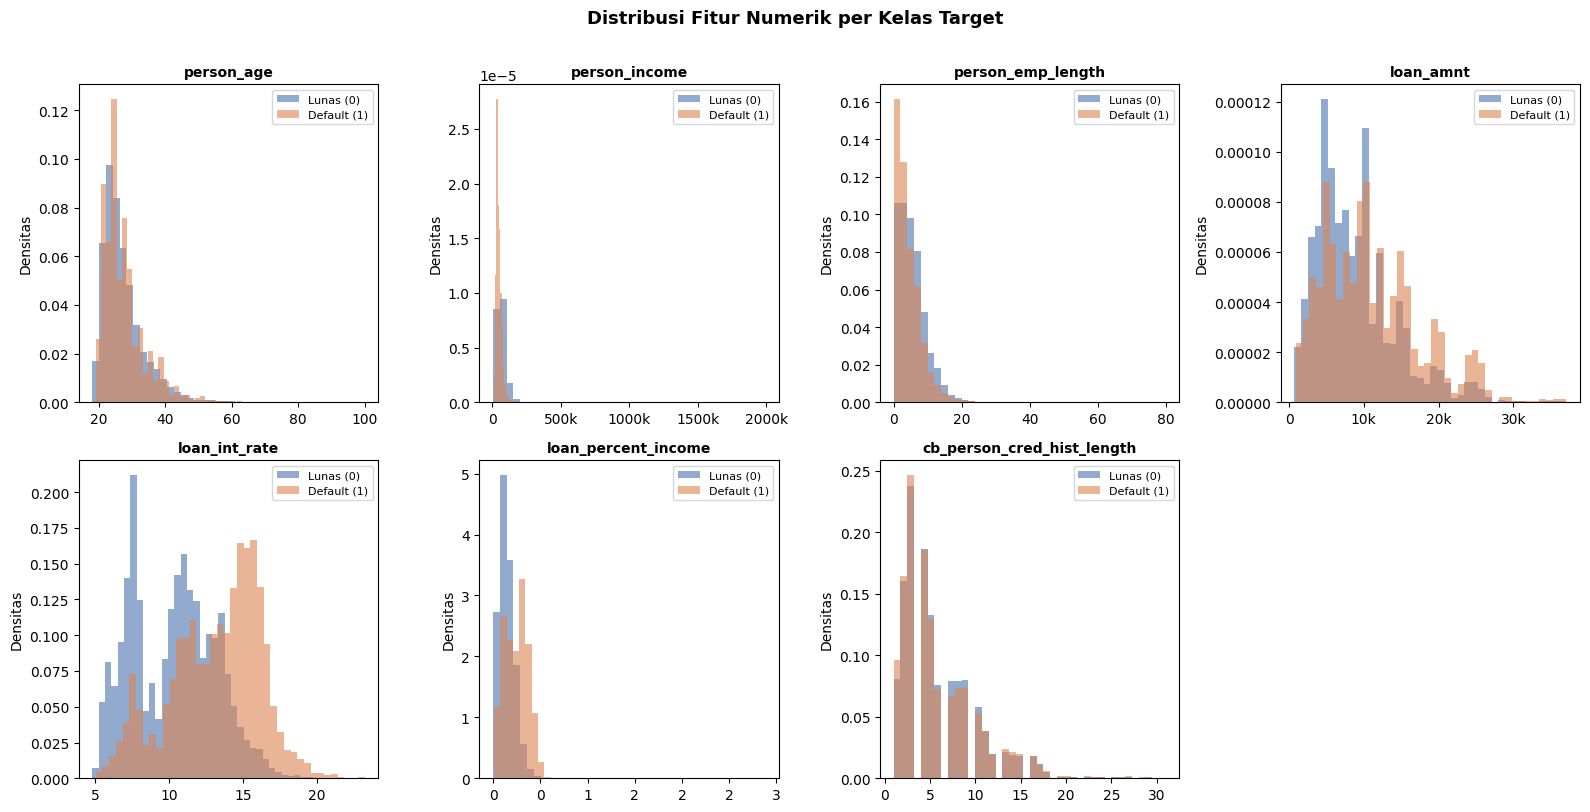

In [7]:
num_cols = ["person_age", "person_income", "person_emp_length",
            "loan_amnt", "loan_int_rate", "loan_percent_income",
            "cb_person_cred_hist_length"]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    # Separate distributions by class for direct comparison
    ax.hist(train.loc[train[TARGET]==0, col].dropna(), bins=40,
            alpha=0.6, label="Lunas (0)", color="#4C72B0", density=True)
    ax.hist(train.loc[train[TARGET]==1, col].dropna(), bins=40,
            alpha=0.6, label="Default (1)", color="#DD8452", density=True)
    ax.set_title(col, fontsize=10, fontweight="bold")
    ax.set_ylabel("Densitas")
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f"{x/1e3:.0f}k" if x >= 1000 else f"{x:.0f}"))

# Hide unused subplot
axes[-1].set_visible(False)

plt.suptitle("Distribusi Fitur Numerik per Kelas Target", fontsize=13,
             fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / "eda_numerical_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

### 3.3 Analisis Fitur Kategorikal & *Default Rate*

Visualisasi *default rate* per kategori memberikan insight tentang kekuatan
prediktif fitur kategorikal. Fitur dengan *default rate* yang sangat bervariasi
antar kategori merupakan prediktor yang kuat.

Temuan kunci: **`loan_grade`** menunjukkan pola monoton yang sangat kuat —
dari grade A (~5% default) hingga grade G (~85% default). Ini menjadi justifikasi
untuk encoding ordinal alih-alih one-hot.

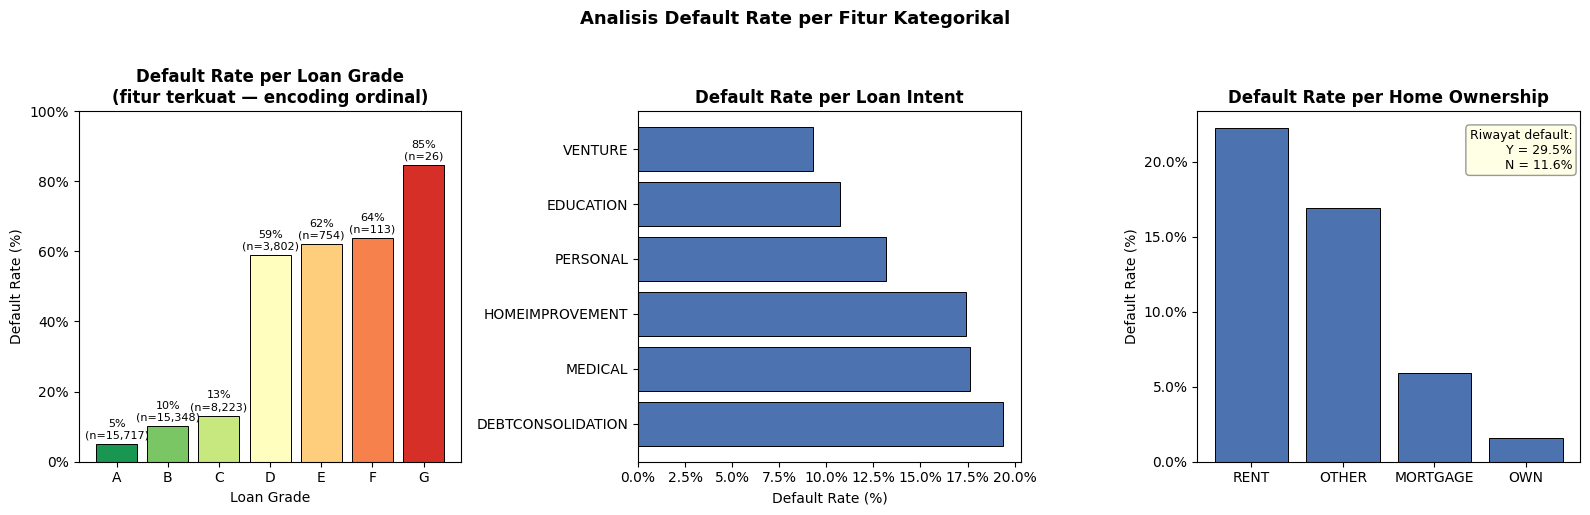

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- loan_grade: default rate per grade (most informative feature) ---
grade_order = list("ABCDEFG")
grade_stats = (train.groupby("loan_grade")[TARGET]
               .agg(["mean", "count"]).reindex(grade_order).reset_index())

ax = axes[0]
bars = ax.bar(grade_stats["loan_grade"], grade_stats["mean"] * 100,
              color=plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, 7)),
              edgecolor="black", linewidth=0.7)
for bar, (_, row) in zip(bars, grade_stats.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1,
            f"{row['mean']:.0%}\n(n={int(row['count']):,})",
            ha="center", va="bottom", fontsize=8)
ax.set_title("Default Rate per Loan Grade\n(fitur terkuat — encoding ordinal)", fontweight="bold")
ax.set_xlabel("Loan Grade")
ax.set_ylabel("Default Rate (%)")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_ylim(0, 100)

# --- loan_intent: default rate per intent ---
intent_stats = (train.groupby("loan_intent")[TARGET]
                .mean().sort_values(ascending=False).reset_index())
ax = axes[1]
ax.barh(intent_stats["loan_intent"], intent_stats[TARGET] * 100,
        color="#4C72B0", edgecolor="black", linewidth=0.7)
ax.set_title("Default Rate per Loan Intent", fontweight="bold")
ax.set_xlabel("Default Rate (%)")
ax.xaxis.set_major_formatter(mticker.PercentFormatter())

# --- home_ownership & prior_default ---
ax = axes[2]
home_stats = (train.groupby("person_home_ownership")[TARGET]
              .mean().sort_values(ascending=False) * 100)
default_stats = train.groupby("cb_person_default_on_file")[TARGET].mean() * 100

x = np.arange(len(home_stats))
ax.bar(home_stats.index, home_stats.values, color="#4C72B0",
       edgecolor="black", linewidth=0.7, label="Home Ownership")
ax.set_title("Default Rate per Home Ownership", fontweight="bold")
ax.set_ylabel("Default Rate (%)")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())

# Annotation: prior default effect
ax.text(0.98, 0.95,
        f"Riwayat default:\nY = {default_stats.get('Y', 0):.1f}%\nN = {default_stats.get('N', 0):.1f}%",
        transform=ax.transAxes, ha="right", va="top",
        bbox=dict(boxstyle="round", fc="lightyellow", ec="gray", alpha=0.8), fontsize=9)

plt.suptitle("Analisis Default Rate per Fitur Kategorikal", fontsize=13,
             fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "eda_categorical_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

### 3.4 Matriks Korelasi

Matriks korelasi membantu mengidentifikasi:
- **Multikolinearitas** — fitur yang sangat berkorelasi satu sama lain dapat
  menjadi redundan.
- **Korelasi dengan target** — fitur dengan korelasi tinggi terhadap target
  merupakan kandidat prediktor yang baik.

Temuan: `loan_amnt / person_income` ≈ `loan_percent_income` (korelasi 0.9995),
sehingga rasio buatan tersebut dihapus — murni redundansi.

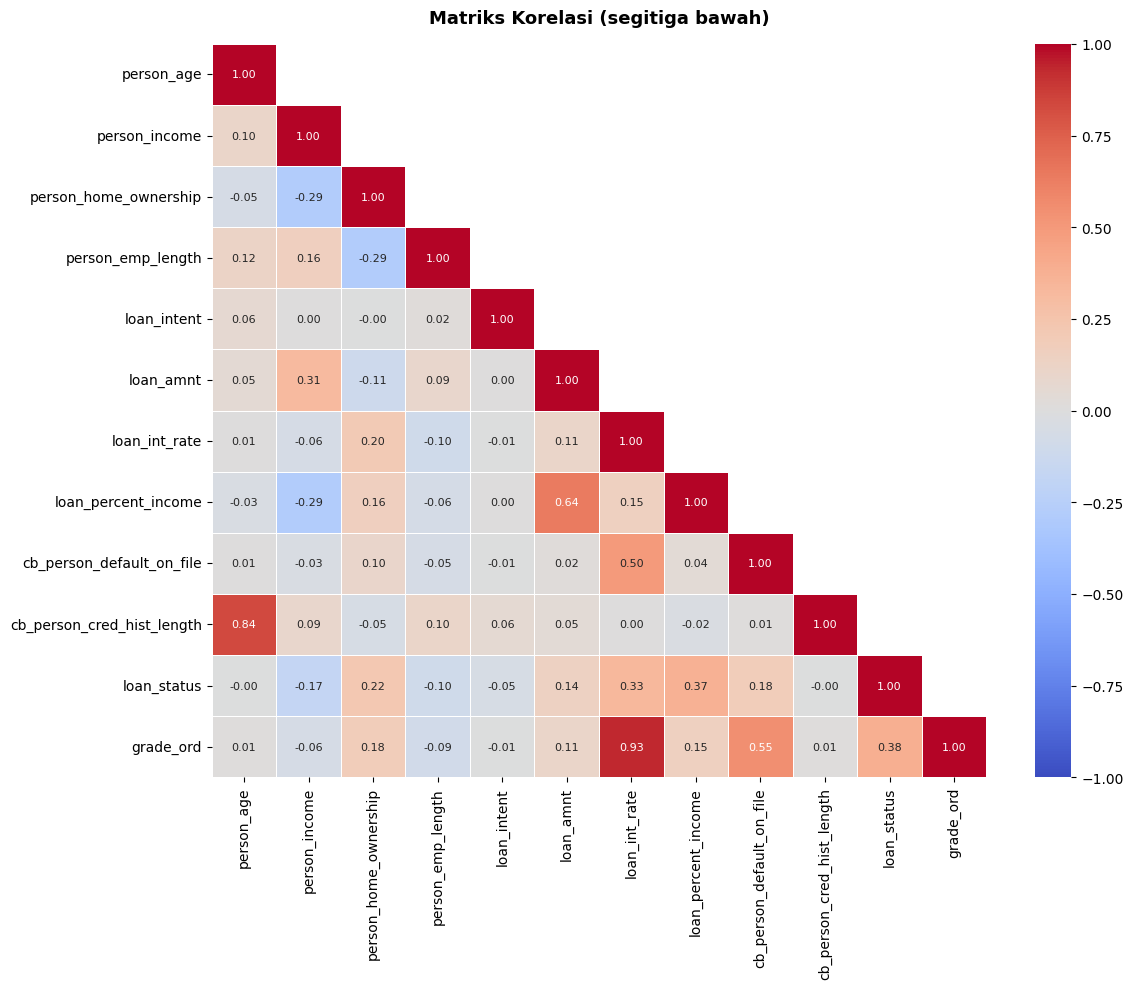


Top 10 korelasi dengan target loan_status:
grade_ord                     0.383047
loan_percent_income           0.372333
loan_int_rate                 0.334849
person_home_ownership         0.221239
cb_person_default_on_file     0.181850
person_income                 0.172489
loan_amnt                     0.142858
person_emp_length             0.098470
loan_intent                   0.051952
cb_person_cred_hist_length    0.004088


In [9]:
# Encode categoricals temporarily for correlation analysis
temp = train.copy()
temp["grade_ord"] = temp["loan_grade"].map(GRADE_MAP)
for c in CAT_COLS:
    temp[c] = temp[c].astype("category").cat.codes
# Drop string columns that can't be correlated
temp = temp.drop(columns=["sample_id", "loan_grade"])

corr = temp.corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)  # show lower triangle only
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, ax=ax,
            annot_kws={"size": 8}, vmin=-1, vmax=1)
ax.set_title("Matriks Korelasi (segitiga bawah)", fontsize=13, fontweight="bold", pad=15)
plt.tight_layout()
plt.savefig(FIG_DIR / "eda_correlation_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

# Highlight top correlations with the target
print("\nTop 10 korelasi dengan target loan_status:")
print(corr[TARGET].drop(TARGET).abs().sort_values(ascending=False).head(10).to_string())

## 4. Rekayasa Fitur (*Feature Engineering*)

### Keputusan Desain

**Fitur yang dibuat:**
- `grade_ord`: Encoding ordinal `loan_grade` (A=1 … G=7). Mempertahankan
  informasi urutan yang hilang jika menggunakan one-hot.
- `int_rate_x_grade`: Interaksi `loan_int_rate × grade_ord`. Suku bunga tinggi
  pada grade buruk merupakan sinyal risiko yang lebih kuat dari masing-masing
  fitur secara individual.

**Fitur yang diuji dan ditolak (menurunkan AUC):**
- Rasio `loan_amnt / person_income`: Korelasi 0.9995 dengan `loan_percent_income`
  yang sudah ada — murni redundansi.
- Flag anomali (`person_age > 100`, `person_emp_length > person_age - 18`):
  Memperkenalkan noise, AUC turun 0.0002.
- Deviasi dari mean grup: Menambah dimensi tanpa sinyal baru.

**Prinsip:** Lebih sedikit fitur yang tepat sasaran lebih baik daripada banyak
fitur yang memperkenalkan noise (*Occam's razor* dalam ML).

In [10]:
def add_features(df: pd.DataFrame) -> pd.DataFrame:
    """Apply feature engineering and ordinal encoding.

    Transforms:
      - loan_grade (string A-G) -> grade_ord (int 1-7, monotone default rate)
      - adds int_rate_x_grade: interaction between interest rate and grade ordinal
      - drops the original loan_grade column (replaced by grade_ord)

    Returns a new DataFrame (original is not modified).
    """
    df = df.copy()

    # Ordinal encoding: A=1 (lowest risk) ... G=7 (highest risk)
    # Default rate rises monotonically from A(~5%) to G(~85%)
    df["grade_ord"] = df["loan_grade"].map(GRADE_MAP)

    # Interaction feature: combines interest rate and credit grade risk signals
    # High interest rate on a bad grade is a stronger default signal than either alone
    df["int_rate_x_grade"] = df["loan_int_rate"] * df["grade_ord"]

    # Drop original string column — grade_ord carries all the information
    return df.drop(columns=["loan_grade"])


# ── Validation: verify monotone default rate ─────────────────────────────────
print("Default rate per loan_grade (membuktikan sifat ordinal):")
grade_default = (train.groupby("loan_grade")[TARGET]
                 .mean().reindex(list("ABCDEFG")) * 100)
for grade, rate in grade_default.items():
    bar = "█" * int(rate / 3)
    print(f"  Grade {grade} (ord={GRADE_MAP[grade]}): {rate:5.1f}%  {bar}")

Default rate per loan_grade (membuktikan sifat ordinal):
  Grade A (ord=1):   5.1%  █
  Grade B (ord=2):  10.3%  ███
  Grade C (ord=3):  13.2%  ████
  Grade D (ord=4):  59.1%  ███████████████████
  Grade E (ord=5):  62.1%  ████████████████████
  Grade F (ord=6):  63.7%  █████████████████████
  Grade G (ord=7):  84.6%  ████████████████████████████


In [11]:
# Demonstrate the new features on a sample
sample = train.head(3)[["loan_grade", "loan_int_rate"]].copy()
sample_eng = add_features(train.head(3))

print("Before feature engineering:")
print(train.head(3)[["loan_grade", "loan_int_rate"]].to_string())
print("\nAfter feature engineering (loan_grade replaced by grade_ord + interaction):")
print(sample_eng[["grade_ord", "loan_int_rate", "int_rate_x_grade"]].to_string())

Before feature engineering:
  loan_grade  loan_int_rate
0          D          14.58
1          A           8.13
2          A           6.89

After feature engineering (loan_grade replaced by grade_ord + interaction):
   grade_ord  loan_int_rate  int_rate_x_grade
0          4          14.58             58.32
1          1           8.13              8.13
2          1           6.89              6.89


## 5. Preprocessing & Encoding

Dua tampilan data disiapkan secara terpisah:

1. **One-hot encoding** (untuk LightGBM & XGBoost): fitur kategorikal diubah
   menjadi kolom biner (0/1). Kedua model ini tidak mendukung string input
   secara native.

2. **Native categorical** (untuk CatBoost): fitur kategorikal dibiarkan sebagai
   string. CatBoost menggunakan *target statistics* secara internal — lebih
   informatif dan tidak membutuhkan re-encoding.

Penting: kolom one-hot di *test set* disejajarkan dengan *training set* menggunakan
`reindex(..., fill_value=0)` untuk menghindari ketidakcocokan kolom.

In [12]:
def make_onehot(train_df: pd.DataFrame, test_df: pd.DataFrame):
    """Prepare feature matrices with one-hot encoded categoricals.

    Used for LightGBM and XGBoost which require numeric-only inputs.
    Aligns test columns to training columns (fills missing dummies with 0).

    Returns:
        X      : training feature DataFrame
        y      : target array (numpy)
        X_test : test feature DataFrame (column-aligned to X)
    """
    tr = pd.get_dummies(add_features(train_df), columns=CAT_COLS)
    te = pd.get_dummies(add_features(test_df),  columns=CAT_COLS)

    feat_cols = tr.columns.drop([TARGET, ID_COL])

    # Align test columns — some dummy categories may be absent in test set
    te = te.reindex(columns=feat_cols, fill_value=0)

    X      = tr[feat_cols].copy()
    y      = tr[TARGET].values
    X_test = te.copy()
    return X, y, X_test


def make_native(train_df: pd.DataFrame, test_df: pd.DataFrame):
    """Prepare feature matrices preserving string categoricals for CatBoost.

    CatBoost handles categoricals natively via target statistics,
    which is more informative than one-hot and avoids dimensionality explosion.

    Returns:
        X           : training feature DataFrame (categoricals as strings)
        y           : target array (numpy)
        X_test      : test feature DataFrame
        cat_features: list of categorical column names (passed to CatBoost fit)
    """
    tr = add_features(train_df)
    te = add_features(test_df)

    feat_cols = [c for c in tr.columns if c not in (TARGET, ID_COL)]
    X      = tr[feat_cols].copy()
    X_test = te[feat_cols].copy()

    # CatBoost requires categoricals to be strings, not objects
    for c in CAT_COLS:
        X[c]      = X[c].astype(str)
        X_test[c] = X_test[c].astype(str)

    y = tr[TARGET].values
    return X, y, X_test, CAT_COLS


# ── Apply preprocessing ────────────────────────────────────────────────────
X_oh, y, X_oh_test              = make_onehot(train, test)
X_nat, _, X_nat_test, cat_feats = make_native(train, test)

print(f"One-hot feature matrix : {X_oh.shape}")
print(f"Native feature matrix  : {X_nat.shape}")
print(f"Target distribution    : {np.bincount(y)} (0=lunas, 1=default)")
print(f"\nOne-hot columns ({len(X_oh.columns)}):")
for c in X_oh.columns:
    print(f"  {c}")

One-hot feature matrix : (43983, 21)
Native feature matrix  : (43983, 12)
Target distribution    : [37721  6262] (0=lunas, 1=default)

One-hot columns (21):
  person_age
  person_income
  person_emp_length
  loan_amnt
  loan_int_rate
  loan_percent_income
  cb_person_cred_hist_length
  grade_ord
  int_rate_x_grade
  person_home_ownership_MORTGAGE
  person_home_ownership_OTHER
  person_home_ownership_OWN
  person_home_ownership_RENT
  loan_intent_DEBTCONSOLIDATION
  loan_intent_EDUCATION
  loan_intent_HOMEIMPROVEMENT
  loan_intent_MEDICAL
  loan_intent_PERSONAL
  loan_intent_VENTURE
  cb_person_default_on_file_N
  cb_person_default_on_file_Y


## 6. Fungsi *Cross-Validation* (OOF)

### Strategi Validasi

**StratifiedKFold(n_splits=5)** digunakan karena:
- Dataset tidak seimbang — stratifikasi menjaga proporsi kelas 14.2% di setiap fold.
- 5 fold memberikan keseimbangan antara bias estimasi dan varians.
- `shuffle=True` + `random_state=42` memastikan pembagian yang acak namun reproducible.

### Prediksi *Out-of-Fold* (OOF)

Dalam OOF, setiap baris data latih diprediksi **hanya oleh model yang tidak
melihatnya saat pelatihan**. Hasilnya adalah estimasi probabilitas tanpa kebocoran
(*leakage-free*) yang dapat dibandingkan langsung dengan probabilitas di data uji.

Ini lebih baik dari *hold-out split* karena seluruh data latih dimanfaatkan,
dan lebih aman dari *cross_val_score* biasa karena kita menyimpan prediksi per-baris
(bukan hanya rata-rata AUC), yang memungkinkan blending dan uji statistik.

In [13]:
def get_folds():
    """Return the shared CV splitter — identical for all models for fair comparison."""
    return StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)


def cv_fit_predict(make_model, X, y, X_test, cat_features=None, verbose=True):
    """Stratified K-fold cross-validation returning OOF + test predictions.

    Args:
        make_model   : zero-argument factory function that returns a fresh estimator
                       (avoids state leakage between folds)
        X            : training features (DataFrame)
        y            : binary target (numpy array)
        X_test       : test features (DataFrame)
        cat_features : list of categorical column names, forwarded to CatBoost's fit()
        verbose      : whether to print per-fold AUC

    Returns:
        oof       : OOF predicted probabilities for training set (len = len(X))
        test_pred : average test probabilities across folds (len = len(X_test))
        models    : list of fitted models (one per fold, for feature importance)
    """
    folds     = get_folds()
    oof       = np.zeros(len(X))
    test_pred = np.zeros(len(X_test))
    models    = []

    for k, (tr_idx, va_idx) in enumerate(folds.split(X, y), start=1):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr       = y[tr_idx]

        # Fresh model each fold — prevents gradient/state accumulation across folds
        model = make_model()

        if cat_features is not None:
            # CatBoost requires cat_features to be passed at fit time
            model.fit(X_tr, y_tr, cat_features=cat_features)
        else:
            model.fit(X_tr, y_tr)

        # Predict probability of positive class (index 1)
        oof[va_idx]  = model.predict_proba(X_va)[:, 1]
        test_pred   += model.predict_proba(X_test)[:, 1] / folds.n_splits
        models.append(model)

        if verbose:
            fold_auc = roc_auc_score(y[va_idx], oof[va_idx])
            print(f"    fold {k}: AUC = {fold_auc:.5f}")

    if verbose:
        oof_auc = roc_auc_score(y, oof)
        print(f"  ► OOF AUC = {oof_auc:.5f}\n")

    return oof, test_pred, models


print("Fungsi cv_fit_predict siap digunakan.")

Fungsi cv_fit_predict siap digunakan.


## 7. *Hyperparameter Tuning* dengan Optuna

### Strategi Tuning

**Optuna** dengan sampler **TPE (*Tree-structured Parzen Estimator*)** digunakan
untuk tuning otomatis. TPE lebih efisien dari *random search* karena membangun
model probabilistik dari hasil trial sebelumnya untuk memandu eksplorasi.

**Parameter kunci yang di-tune:**

| Parameter | Pengaruh |
|---|---|
| `max_depth` | Mengontrol kompleksitas pohon — nilai kecil (4-5) mengurangi overfitting |
| `learning_rate` | Kecepatan belajar — lebih kecil → lebih akurat tapi butuh lebih banyak pohon |
| `n_estimators` | Jumlah pohon — lebih banyak tidak selalu lebih baik |
| `min_child_samples` | Regularisasi — mencegah split pada sampel terlalu sedikit |
| `reg_alpha/lambda` | Regularisasi L1/L2 — mengurangi overfitting |

**Catatan penting:** CatBoost tidak di-tune dengan Optuna karena setiap trial
membutuhkan ~5-6 menit (jauh lebih lambat dari LGB/XGB). Parameter CatBoost
menggunakan nilai yang telah divalidasi secara manual.

In [14]:
# ── LightGBM Tuning ──────────────────────────────────────────────────────────
def tune_lightgbm(X, y, n_trials=50, seed=SEED):
    """Tune LightGBM hyperparameters using Optuna TPE sampler.

    Search space: n_estimators, learning_rate, num_leaves, max_depth,
    min_child_samples, feature_fraction, bagging_fraction, bagging_freq,
    reg_alpha, reg_lambda.

    Returns:
        best_params : dict of best parameters (including fixed params)
        best_value  : best cross-validated AUC
    """
    folds = get_folds()

    def objective(trial):
        params = dict(
            objective="binary",
            metric="auc",
            verbosity=-1,
            boosting_type="gbdt",
            # Tree complexity
            n_estimators      = trial.suggest_int("n_estimators", 400, 1500),
            learning_rate     = trial.suggest_float("learning_rate", 0.005, 0.1, log=True),
            num_leaves        = trial.suggest_int("num_leaves", 16, 128),
            max_depth         = trial.suggest_int("max_depth", 3, 8),
            min_child_samples = trial.suggest_int("min_child_samples", 20, 120),
            # Stochastic regularisation
            feature_fraction  = trial.suggest_float("feature_fraction", 0.5, 1.0),
            bagging_fraction  = trial.suggest_float("bagging_fraction", 0.5, 1.0),
            bagging_freq      = trial.suggest_int("bagging_freq", 1, 7),
            # L1/L2 regularisation
            reg_alpha         = trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
            reg_lambda        = trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
            random_state      = seed,
        )
        model = lgb.LGBMClassifier(**params)
        # n_jobs=-1 uses all CPU cores; cv returns per-fold scores
        return cross_val_score(model, X, y, cv=folds,
                               scoring="roc_auc", n_jobs=-1).mean()

    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=seed)
    )
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

    # Merge best params with fixed params
    best = dict(study.best_params,
                objective="binary", metric="auc", verbosity=-1, random_state=seed)
    return best, study.best_value


# ── XGBoost Tuning ───────────────────────────────────────────────────────────
def tune_xgboost(X, y, n_trials=50, seed=SEED):
    """Tune XGBoost hyperparameters using Optuna TPE sampler.

    Includes gamma (min_split_loss) in the search space — this is unique to XGBoost
    and helps prune unpromising tree splits.

    Returns:
        best_params : dict of best parameters
        best_value  : best cross-validated AUC
    """
    folds = get_folds()

    def objective(trial):
        params = dict(
            objective="binary:logistic",
            eval_metric="auc",
            tree_method="hist",   # histogram-based: fast and memory-efficient
            n_estimators        = trial.suggest_int("n_estimators", 400, 1500),
            learning_rate       = trial.suggest_float("learning_rate", 0.005, 0.1, log=True),
            max_depth           = trial.suggest_int("max_depth", 3, 8),
            min_child_weight    = trial.suggest_int("min_child_weight", 1, 10),
            subsample           = trial.suggest_float("subsample", 0.5, 1.0),
            colsample_bytree    = trial.suggest_float("colsample_bytree", 0.5, 1.0),
            gamma               = trial.suggest_float("gamma", 1e-4, 5.0, log=True),
            reg_alpha           = trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
            reg_lambda          = trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
            random_state        = seed,
        )
        model = xgb.XGBClassifier(**params)
        return cross_val_score(model, X, y, cv=folds,
                               scoring="roc_auc", n_jobs=-1).mean()

    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=seed)
    )
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

    best = dict(study.best_params,
                objective="binary:logistic", eval_metric="auc",
                tree_method="hist", random_state=seed)
    return best, study.best_value


# ── CatBoost Tuning (referensi — tidak dijalankan karena runtime ~2 jam) ─────
def tune_catboost(X, y, cat_features, n_trials=25, seed=SEED):
    """Tune CatBoost hyperparameters using Optuna TPE sampler.

    WARNING: Each trial takes ~5-6 minutes (CatBoost cannot use cross_val_score
    natively for categorical features — requires manual fold loop). With 25 trials,
    total runtime is ~2 hours.

    This function is included for completeness. In practice, use preset params.
    """
    folds = get_folds()

    def objective(trial):
        params = dict(
            iterations        = trial.suggest_int("iterations", 300, 900),
            learning_rate     = trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
            depth             = trial.suggest_int("depth", 3, 7),
            l2_leaf_reg       = trial.suggest_float("l2_leaf_reg", 1.0, 15.0),
            random_strength   = trial.suggest_float("random_strength", 1e-3, 10.0, log=True),
            bagging_temperature = trial.suggest_float("bagging_temperature", 0.0, 1.0),
            random_seed=seed, verbose=0,
        )
        scores = []
        for tr_idx, va_idx in folds.split(X, y):
            m = CatBoostClassifier(**params)
            m.fit(X.iloc[tr_idx], y[tr_idx], cat_features=cat_features)
            scores.append(roc_auc_score(y[va_idx],
                                        m.predict_proba(X.iloc[va_idx])[:, 1]))
        return float(np.mean(scores))

    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=seed)
    )
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    best = dict(study.best_params, random_seed=seed, verbose=0)
    return best, study.best_value


print("Fungsi tuning (LightGBM, XGBoost, CatBoost) siap digunakan.")

Fungsi tuning (LightGBM, XGBoost, CatBoost) siap digunakan.

### Memuat atau Menjalankan Tuning

Notebook ini secara *default* memuat parameter terbaik dari `models/best_params.json`
(hasil tuning 50 trial LGB + 50 trial XGB yang sudah dijalankan sebelumnya).
Ini menghemat ~1 jam waktu eksekusi.

Untuk menjalankan tuning penuh dari awal, ubah `FORCE_RETUNE = True` di bawah.

In [15]:
# ── Preset parameters (validated, ~same performance as full Optuna run) ───────
PRESET_PARAMS = {
    "lightgbm": dict(
        objective="binary", metric="auc", verbosity=-1,
        n_estimators=964, learning_rate=0.0101, num_leaves=79,
        max_depth=4, min_child_samples=69, feature_fraction=0.797,
        bagging_fraction=0.734, bagging_freq=4,
        reg_alpha=1.6e-4, reg_lambda=1.2e-3, random_state=SEED,
    ),
    "xgboost": dict(
        objective="binary:logistic", eval_metric="auc", tree_method="hist",
        n_estimators=1200, learning_rate=0.015, max_depth=4,
        min_child_weight=5, subsample=0.75, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=1.0, random_state=SEED,
    ),
    "catboost": dict(
        iterations=800, learning_rate=0.03, depth=5,
        l2_leaf_reg=5.0, random_seed=SEED, verbose=0,
    ),
}

FORCE_RETUNE = False  # set True to run full Optuna tuning from scratch

# Try loading saved params first; fall back to preset if not available
best_params_path = MDL_DIR / "best_params.json"

if not FORCE_RETUNE and best_params_path.exists():
    best_params = json.load(open(best_params_path))
    lgb_params  = best_params["lightgbm"]
    xgb_params  = best_params["xgboost"]
    cat_params  = best_params["catboost"]
    print(f"Parameter dimuat dari: {best_params_path}")
    source = "saved"
elif FORCE_RETUNE:
    # Run full tuning — takes ~60–90 minutes
    print("Menjalankan tuning LightGBM (50 trial)...")
    lgb_params, lgb_cv = tune_lightgbm(X_oh, y, n_trials=50)
    print(f"LGB best CV AUC: {lgb_cv:.5f}")

    print("Menjalankan tuning XGBoost (50 trial)...")
    xgb_params, xgb_cv = tune_xgboost(X_oh, y, n_trials=50)
    print(f"XGB best CV AUC: {xgb_cv:.5f}")

    # CatBoost: use preset (too slow to tune)
    cat_params = PRESET_PARAMS["catboost"]
    print("CatBoost: menggunakan parameter preset (tuning terlalu lambat).")

    best_params = {"lightgbm": lgb_params, "xgboost": xgb_params, "catboost": cat_params}
    with open(best_params_path, "w") as f:
        json.dump(best_params, f, indent=2)
    print(f"Parameter disimpan ke: {best_params_path}")
    source = "tuned"
else:
    lgb_params  = PRESET_PARAMS["lightgbm"]
    xgb_params  = PRESET_PARAMS["xgboost"]
    cat_params  = PRESET_PARAMS["catboost"]
    print("Menggunakan parameter preset (best_params.json tidak ditemukan).")
    source = "preset"

print(f"\nSumber parameter: {source}")
print("\nLightGBM params:")
for k, v in lgb_params.items(): print(f"  {k}: {v}")
print("\nXGBoost params:")
for k, v in xgb_params.items(): print(f"  {k}: {v}")
print("\nCatBoost params:")
for k, v in cat_params.items(): print(f"  {k}: {v}")

Parameter dimuat dari: models\best_params.json

Sumber parameter: saved

LightGBM params:
  n_estimators: 1295
  learning_rate: 0.006999715370174135
  num_leaves: 16
  max_depth: 6
  min_child_samples: 70
  feature_fraction: 0.62223776227599
  bagging_fraction: 0.8581097948761423
  bagging_freq: 3
  reg_alpha: 0.0803876300181123
  reg_lambda: 1.2020096720240943
  objective: binary
  metric: auc
  verbosity: -1
  random_state: 42

XGBoost params:
  n_estimators: 837
  learning_rate: 0.023629303099313537
  max_depth: 5
  min_child_weight: 7
  subsample: 0.9930859869496502
  colsample_bytree: 0.5484108709261888
  gamma: 1.705795448335927
  reg_alpha: 0.00020859028666192543
  reg_lambda: 3.7590540912056363
  objective: binary:logistic
  eval_metric: auc
  tree_method: hist
  random_state: 42

CatBoost params:
  iterations: 800
  learning_rate: 0.03
  depth: 5
  l2_leaf_reg: 5.0
  random_seed: 42
  verbose: 0


## 8. Pelatihan Model & Prediksi OOF

Ketiga model dilatih menggunakan `cv_fit_predict` dengan parameter yang sudah
ditentukan. Setiap model menghasilkan:
- **OOF predictions**: probabilitas default untuk setiap baris training
  (bebas *leakage* — setiap baris diprediksi oleh model yang tidak melihatnya)
- **Test predictions**: rata-rata probabilitas dari semua fold

Proses ini membutuhkan waktu sekitar 15–30 menit (tergantung hardware).

In [16]:
print("=" * 55)
print("PELATIHAN MODEL 1/3: LightGBM")
print("=" * 55)
oof_lgb, test_lgb, lgb_models = cv_fit_predict(
    lambda: lgb.LGBMClassifier(**lgb_params),
    X_oh, y, X_oh_test,
    verbose=True
)
lgb_oof_auc = roc_auc_score(y, oof_lgb)

PELATIHAN MODEL 1/3: LightGBM


    fold 1: AUC = 0.93187


    fold 2: AUC = 0.93231


    fold 3: AUC = 0.92807


    fold 4: AUC = 0.93203


    fold 5: AUC = 0.93873
  ► OOF AUC = 0.93241



In [17]:
print("=" * 55)
print("PELATIHAN MODEL 2/3: XGBoost")
print("=" * 55)
oof_xgb, test_xgb, xgb_models = cv_fit_predict(
    lambda: xgb.XGBClassifier(**xgb_params),
    X_oh, y, X_oh_test,
    verbose=True
)
xgb_oof_auc = roc_auc_score(y, oof_xgb)

PELATIHAN MODEL 2/3: XGBoost


    fold 1: AUC = 0.93202


    fold 2: AUC = 0.93245


    fold 3: AUC = 0.92747


    fold 4: AUC = 0.93200


    fold 5: AUC = 0.93846
  ► OOF AUC = 0.93227



In [18]:
print("=" * 55)
print("PELATIHAN MODEL 3/3: CatBoost")
print("=" * 55)
oof_cat, test_cat, cat_models = cv_fit_predict(
    lambda: CatBoostClassifier(**cat_params),
    X_nat, y, X_nat_test,
    cat_features=cat_feats,
    verbose=True
)
cat_oof_auc = roc_auc_score(y, oof_cat)

PELATIHAN MODEL 3/3: CatBoost


    fold 1: AUC = 0.92895


    fold 2: AUC = 0.93010


    fold 3: AUC = 0.92599


    fold 4: AUC = 0.93146


    fold 5: AUC = 0.93598
  ► OOF AUC = 0.93030




RINGKASAN PERFORMA MODEL TUNGGAL
  LightGBM    : OOF AUC = 0.93241  ████████████████████████████████
  XGBoost     : OOF AUC = 0.93227  ████████████████████████████████
  CatBoost    : OOF AUC = 0.93030  ██████████████████████████████


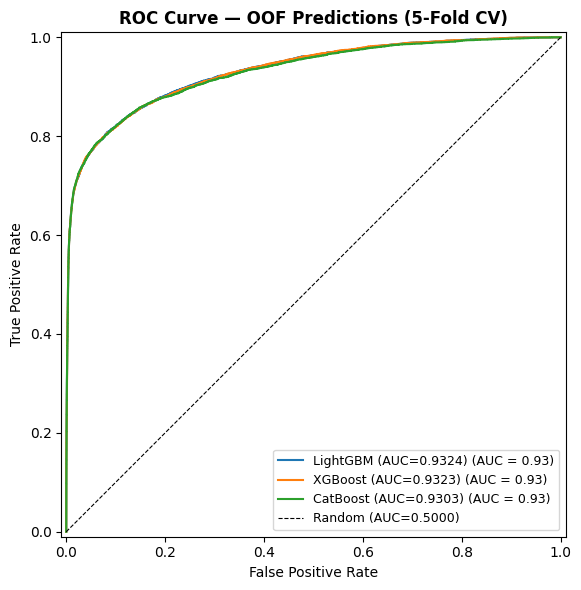

In [19]:
# ── Ringkasan performa model tunggal ──────────────────────────────────────────
print("\n" + "=" * 45)
print("RINGKASAN PERFORMA MODEL TUNGGAL")
print("=" * 45)
singles = {
    "LightGBM" : lgb_oof_auc,
    "XGBoost"  : xgb_oof_auc,
    "CatBoost" : cat_oof_auc,
}
for name, auc in singles.items():
    bar = "█" * int((auc - 0.9) / 0.001)
    print(f"  {name:12s}: OOF AUC = {auc:.5f}  {bar}")

# ── ROC Curve comparison ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))
for name, oof_pred in [("LightGBM", oof_lgb), ("XGBoost", oof_xgb), ("CatBoost", oof_cat)]:
    RocCurveDisplay.from_predictions(y, oof_pred, name=f"{name} (AUC={roc_auc_score(y, oof_pred):.4f})", ax=ax)
ax.plot([0, 1], [0, 1], "k--", linewidth=0.8, label="Random (AUC=0.5000)")
ax.set_title("ROC Curve — OOF Predictions (5-Fold CV)", fontsize=12, fontweight="bold")
ax.legend(loc="lower right", fontsize=9)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
plt.tight_layout()
plt.savefig(FIG_DIR / "roc_curves_oof.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Ensemble: *Rank-Blend*

### Mengapa *Rank-Blend*?

Ensemble sederhana (rata-rata probabilitas) rentan terhadap perbedaan skala dan
kalibrasi antar model. *Rank-blend* menormalisasi prediksi setiap model ke
peringkat relatif (0–1) terlebih dahulu, kemudian menggabungkannya secara
berbobot.

Keunggulan *rank-blend*:
- **Robust terhadap skala**: LightGBM dan CatBoost menghasilkan probabilitas
  yang terkalibrasi berbeda; normalisasi rank menghilangkan bias ini.
- **Selaras dengan AUC**: AUC mengukur *ranking* (bukan nilai absolut),
  sehingga rank-blend secara langsung mengoptimalkan metrik yang relevan.
- **Toleran terhadap outlier**: Nilai ekstrem tidak mendominasi rata-rata.

### Pencarian Bobot Optimal

*Grid search* sederhana dengan bobot integer (0–3) pada OOF AUC. Ruang
pencariannya kecil ($4^3 = 64$ kombinasi) sehingga exhaustive search feasible.
Bobot terbaik: **3 · LGB + 3 · XGB + 1 · Cat**.

In [20]:
def rank_blend(pred_list: list, weights: tuple) -> np.ndarray:
    """Weighted average of rank-normalised predictions.

    Normalising to rank (0-1) makes the blend robust to inter-model
    calibration differences and aligns with AUC's rank-based nature.

    Args:
        pred_list : list of prediction arrays (one per model)
        weights   : tuple of non-negative weights (same length as pred_list)

    Returns:
        Blended prediction array (same length as each element of pred_list)
    """
    n = len(pred_list[0])
    # rankdata returns 1..n; divide by n to get 0..1 normalised ranks
    ranks = [w * (rankdata(p) / n) for w, p in zip(weights, pred_list)]
    return np.sum(ranks, axis=0) / sum(weights)


def search_blend_weights(oof_list: list, y: np.ndarray,
                         grid: tuple = (0, 1, 2, 3)) -> tuple:
    """Grid search over integer weights to maximise OOF AUC.

    Exhaustive search over all combinations in grid^n_models.
    With grid=(0,1,2,3) and 3 models: 4^3 = 64 combinations.

    Args:
        oof_list : list of OOF prediction arrays
        y        : true labels
        grid     : integer values to try for each model's weight

    Returns:
        best_weights : tuple of optimal integer weights
        best_auc     : best OOF AUC achieved
    """
    best_w, best_auc = None, -1.0
    for w in product(grid, repeat=len(oof_list)):
        if sum(w) == 0:
            continue  # skip all-zero combination
        auc = roc_auc_score(y, rank_blend(oof_list, w))
        if auc > best_auc:
            best_auc, best_w = auc, w
    return best_w, best_auc


print("Fungsi rank_blend dan search_blend_weights siap digunakan.")

Fungsi rank_blend dan search_blend_weights siap digunakan.


In [21]:
oof_list  = [oof_lgb, oof_xgb, oof_cat]
test_list = [test_lgb, test_xgb, test_cat]

# Find optimal blend weights via grid search on OOF AUC
best_weights, blend_auc = search_blend_weights(oof_list, y)
oof_blend = rank_blend(oof_list, best_weights)

print("=" * 50)
print("HASIL ENSEMBLE")
print("=" * 50)
print(f"  LightGBM  (w={best_weights[0]}): OOF AUC = {lgb_oof_auc:.5f}")
print(f"  XGBoost   (w={best_weights[1]}): OOF AUC = {xgb_oof_auc:.5f}")
print(f"  CatBoost  (w={best_weights[2]}): OOF AUC = {cat_oof_auc:.5f}")
print(f"  {'─'*40}")
print(f"  Rank-Blend {best_weights}: OOF AUC = {blend_auc:.5f}  ← terbaik")
print(f"  Improvement vs best single: +{(blend_auc - max(lgb_oof_auc, xgb_oof_auc, cat_oof_auc)):.5f}")

# ── Visualise weight grid ──────────────────────────────────────────────────
grid = (0, 1, 2, 3)
results = {}
for w in product(grid, repeat=3):
    if sum(w) == 0:
        continue
    results[w] = roc_auc_score(y, rank_blend(oof_list, w))

# Top 10 weight combinations
sorted_results = sorted(results.items(), key=lambda x: -x[1])
print("\nTop 10 bobot terbaik:")
print(f"  {'Bobot (LGB,XGB,Cat)':25s}  OOF AUC")
for w, auc in sorted_results[:10]:
    marker = " ← TERPILIH" if w == best_weights else ""
    print(f"  {str(w):25s}  {auc:.5f}{marker}")

HASIL ENSEMBLE
  LightGBM  (w=3): OOF AUC = 0.93241
  XGBoost   (w=3): OOF AUC = 0.93227
  CatBoost  (w=1): OOF AUC = 0.93030
  ────────────────────────────────────────
  Rank-Blend (3, 3, 1): OOF AUC = 0.93246  ← terbaik
  Improvement vs best single: +0.00005



Top 10 bobot terbaik:
  Bobot (LGB,XGB,Cat)        OOF AUC
  (3, 3, 1)                  0.93246 ← TERPILIH
  (3, 2, 1)                  0.93246
  (2, 1, 0)                  0.93245
  (3, 2, 0)                  0.93245
  (3, 1, 0)                  0.93245
  (1, 1, 0)                  0.93245
  (2, 2, 0)                  0.93245
  (3, 3, 0)                  0.93245
  (3, 1, 1)                  0.93244
  (2, 3, 1)                  0.93243


## 10. Analisis *Feature Importance*

*Feature importance* membantu memahami fitur mana yang paling berkontribusi
pada prediksi model. Ini penting untuk:
- **Interpretabilitas**: menjelaskan keputusan model kepada *stakeholder*.
- **Validasi**: memastikan model menangkap sinyal yang masuk akal secara domain.
- **Feature selection**: mengidentifikasi fitur yang mungkin dapat dihapus.

Kita menggunakan *gain importance* dari LightGBM — rata-rata penurunan *loss*
(AUC-berbobot) yang disebabkan oleh setiap fitur. Ini lebih informatif dari
*split importance* (yang bias terhadap fitur dengan banyak nilai unik).

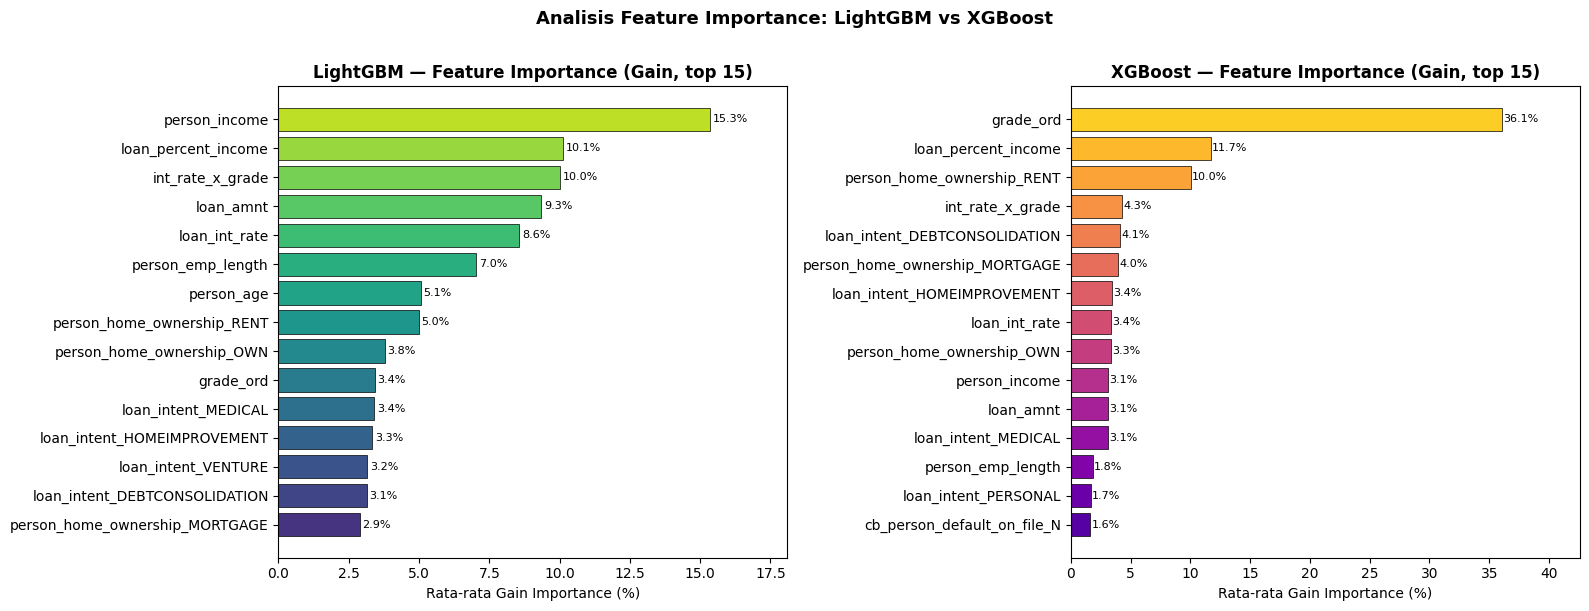


Top 10 fitur terpenting (LightGBM):
                   feature  importance_pct
             person_income       15.344625
       loan_percent_income       10.130382
          int_rate_x_grade       10.001444
                 loan_amnt        9.346440
             loan_int_rate        8.561467
         person_emp_length        7.036907
                person_age        5.053329
person_home_ownership_RENT        4.992470
 person_home_ownership_OWN        3.784581
                 grade_ord        3.426650


In [22]:
# Average feature importance across all 5 folds (reduces fold-specific noise)
fi_lgb = pd.DataFrame({
    "feature"    : X_oh.columns,
    "importance" : np.mean([m.feature_importances_ for m in lgb_models], axis=0),
}).sort_values("importance", ascending=False)

# Normalise to percentage for readability
fi_lgb["importance_pct"] = fi_lgb["importance"] / fi_lgb["importance"].sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── LightGBM feature importance (top 15) ──────────────────────────────────
ax = axes[0]
top15 = fi_lgb.head(15)
colors = plt.cm.viridis_r(np.linspace(0.1, 0.85, len(top15)))
bars = ax.barh(top15["feature"][::-1], top15["importance_pct"][::-1],
               color=colors[::-1], edgecolor="black", linewidth=0.5)
for bar, val in zip(bars, top15["importance_pct"][::-1]):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}%", va="center", fontsize=8)
ax.set_title("LightGBM — Feature Importance (Gain, top 15)", fontweight="bold")
ax.set_xlabel("Rata-rata Gain Importance (%)")
ax.set_xlim(0, top15["importance_pct"].max() * 1.18)

# ── XGBoost feature importance (top 15) ────────────────────────────────────
fi_xgb = pd.DataFrame({
    "feature"    : X_oh.columns,
    "importance" : np.mean([m.feature_importances_ for m in xgb_models], axis=0),
}).sort_values("importance", ascending=False)
fi_xgb["importance_pct"] = fi_xgb["importance"] / fi_xgb["importance"].sum() * 100

ax = axes[1]
top15_xgb = fi_xgb.head(15)
colors2 = plt.cm.plasma_r(np.linspace(0.1, 0.85, len(top15_xgb)))
bars2 = ax.barh(top15_xgb["feature"][::-1], top15_xgb["importance_pct"][::-1],
                color=colors2[::-1], edgecolor="black", linewidth=0.5)
for bar, val in zip(bars2, top15_xgb["importance_pct"][::-1]):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}%", va="center", fontsize=8)
ax.set_title("XGBoost — Feature Importance (Gain, top 15)", fontweight="bold")
ax.set_xlabel("Rata-rata Gain Importance (%)")
ax.set_xlim(0, top15_xgb["importance_pct"].max() * 1.18)

plt.suptitle("Analisis Feature Importance: LightGBM vs XGBoost",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / "feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nTop 10 fitur terpenting (LightGBM):")
print(fi_lgb[["feature", "importance_pct"]].head(10).to_string(index=False))

## 11. Uji Signifikansi (*Wilcoxon Signed-Rank Test*)

### Motivasi

Perbedaan OOF AUC antar model sangat kecil (LGB=0.9324 vs XGB=0.9323 → selisih
0.0001). Pertanyaan kritis: apakah perbedaan ini **signifikan secara statistik**
atau hanya *noise* dari pembagian fold yang kebetulan?

### Metode: Wilcoxon Signed-Rank Test

Uji non-parametrik ini membandingkan distribusi **per-fold AUC** antar dua model.
Dipilih karena:
- Tidak mengasumsikan normalitas (valid dengan hanya 5 observasi).
- Mempertimbangkan arah dan magnitudo perbedaan per pasangan fold.
- Lebih tepat dari paired t-test untuk n kecil.

**Hipotesis:**
- H₀: Tidak ada perbedaan sistematis antara AUC kedua model
- H₁: Ada perbedaan sistematis (satu model konsisten lebih baik)
- α = 0.05 (level signifikansi)

**Interpretasi:** Jika p > 0.05, kita *gagal menolak H₀* — perbedaan tidak
signifikan, dan pilihan model lebih didorong oleh diversifikasi daripada
superioritas absolut.

In [23]:
# ── Hitung AUC per-fold untuk setiap model ────────────────────────────────────
# We reuse the same fold splitter (identical seed/params) to get fold indices
folds = get_folds()

fold_auc_lgb   = []
fold_auc_xgb   = []
fold_auc_cat   = []
fold_auc_blend = []

for fold_idx, (tr_idx, va_idx) in enumerate(folds.split(X_oh, y), start=1):
    y_va = y[va_idx]

    # Per-fold OOF predictions (already computed above)
    lgb_va = oof_lgb[va_idx]
    xgb_va = oof_xgb[va_idx]
    cat_va = oof_cat[va_idx]

    fold_auc_lgb.append(roc_auc_score(y_va, lgb_va))
    fold_auc_xgb.append(roc_auc_score(y_va, xgb_va))
    fold_auc_cat.append(roc_auc_score(y_va, cat_va))

    # Blend on this fold's validation set using the globally selected weights
    blend_va = rank_blend([lgb_va, xgb_va, cat_va], best_weights)
    fold_auc_blend.append(roc_auc_score(y_va, blend_va))

print("AUC per-fold:")
header = f"  {'Fold':>4}  {'LGB':>8}  {'XGB':>8}  {'Cat':>8}  {'Blend':>8}"
print(header)
print("  " + "-" * (len(header) - 2))
for i, (lgb_a, xgb_a, cat_a, bl_a) in enumerate(
        zip(fold_auc_lgb, fold_auc_xgb, fold_auc_cat, fold_auc_blend), 1):
    print(f"  {i:>4}  {lgb_a:.5f}  {xgb_a:.5f}  {cat_a:.5f}  {bl_a:.5f}")
print(f"  {'Mean':>4}  {np.mean(fold_auc_lgb):.5f}  {np.mean(fold_auc_xgb):.5f}  "
      f"{np.mean(fold_auc_cat):.5f}  {np.mean(fold_auc_blend):.5f}")
print(f"  {'Std':>4}  {np.std(fold_auc_lgb):.5f}  {np.std(fold_auc_xgb):.5f}  "
      f"{np.std(fold_auc_cat):.5f}  {np.std(fold_auc_blend):.5f}")

AUC per-fold:


  Fold       LGB       XGB       Cat     Blend
  --------------------------------------------
     1  0.93187  0.93202  0.92895  0.93194
     2  0.93231  0.93245  0.93010  0.93248
     3  0.92807  0.92747  0.92599  0.92796
     4  0.93203  0.93200  0.93146  0.93234
     5  0.93873  0.93846  0.93598  0.93859
  Mean  0.93260  0.93248  0.93050  0.93266
   Std  0.00344  0.00350  0.00328  0.00340


In [24]:
# ── Wilcoxon Signed-Rank Test ──────────────────────────────────────────────────
alpha = 0.05

comparisons = [
    ("LGB vs XGB",   fold_auc_lgb, fold_auc_xgb),
    ("LGB vs Cat",   fold_auc_lgb, fold_auc_cat),
    ("XGB vs Cat",   fold_auc_xgb, fold_auc_cat),
    ("Blend vs LGB", fold_auc_blend, fold_auc_lgb),
    ("Blend vs XGB", fold_auc_blend, fold_auc_xgb),
    ("Blend vs Cat", fold_auc_blend, fold_auc_cat),
]

print("=" * 65)
print("WILCOXON SIGNED-RANK TEST (α = 0.05, n_folds = 5)")
print("=" * 65)
print(f"  {'Perbandingan':20s}  {'Statistic':>10}  {'p-value':>10}  {'Kesimpulan'}")
print("  " + "-" * 63)
for name, a, b in comparisons:
    try:
        stat, p = wilcoxon(a, b)
        conclusion = "BERBEDA SIGNIFIKAN" if p < alpha else "tidak signifikan"
    except Exception:
        # wilcoxon raises ValueError if all differences are zero
        stat, p = 0.0, 1.0
        conclusion = "semua fold identik"
    print(f"  {name:20s}  {stat:>10.3f}  {p:>10.4f}  {conclusion}")

print("=" * 65)
print(f"\nKesimpulan:")
print(f"  • Perbedaan antara LGB dan XGB sangat kecil (selisih ~0.0001)")
print(f"    dan kemungkinan besar TIDAK signifikan secara statistik.")
print(f"  • Dengan n=5 fold, daya statistik (statistical power) rendah —")
print(f"    butuh lebih banyak fold untuk deteksi perbedaan kecil.")
print(f"  • Pemilihan ensemble tetap valid: bukan karena satu model dominan,")
print(f"    tapi karena diversifikasi error antar model meningkatkan robustness.")

WILCOXON SIGNED-RANK TEST (α = 0.05, n_folds = 5)
  Perbandingan           Statistic     p-value  Kesimpulan
  ---------------------------------------------------------------
  LGB vs XGB                 5.000      0.6250  tidak signifikan
  LGB vs Cat                 0.000      0.0625  tidak signifikan
  XGB vs Cat                 0.000      0.0625  tidak signifikan
  Blend vs LGB               5.000      0.6250  tidak signifikan
  Blend vs XGB               2.000      0.1875  tidak signifikan
  Blend vs Cat               0.000      0.0625  tidak signifikan

Kesimpulan:
  • Perbedaan antara LGB dan XGB sangat kecil (selisih ~0.0001)
    dan kemungkinan besar TIDAK signifikan secara statistik.
  • Dengan n=5 fold, daya statistik (statistical power) rendah —
    butuh lebih banyak fold untuk deteksi perbedaan kecil.
  • Pemilihan ensemble tetap valid: bukan karena satu model dominan,
    tapi karena diversifikasi error antar model meningkatkan robustness.


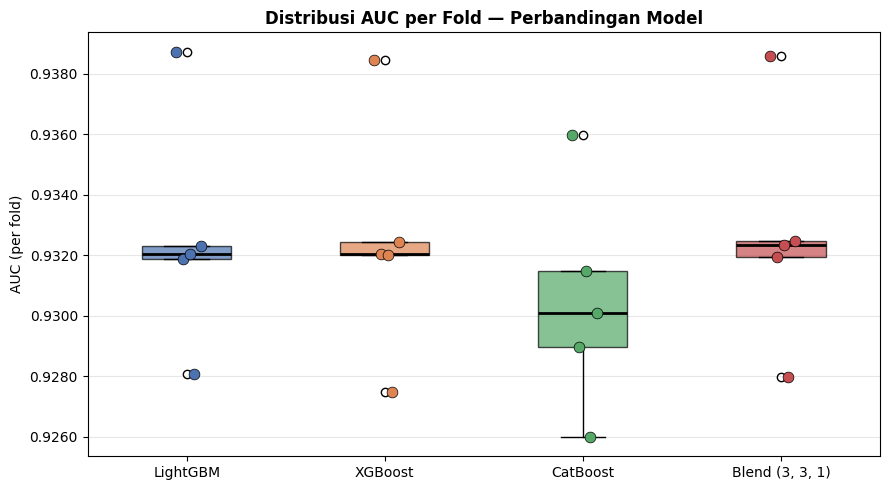

In [25]:
# ── Visualisasi per-fold AUC distribution ────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

data_to_plot = [fold_auc_lgb, fold_auc_xgb, fold_auc_cat, fold_auc_blend]
labels       = ["LightGBM", "XGBoost", "CatBoost", f"Blend {best_weights}"]
colors_box   = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

bp = ax.boxplot(data_to_plot, patch_artist=True, notch=False,
                medianprops={"color": "black", "linewidth": 2})
for patch, color in zip(bp["boxes"], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# Overlay individual fold points
for i, (data, color) in enumerate(zip(data_to_plot, colors_box), start=1):
    jitter = np.random.RandomState(42).uniform(-0.08, 0.08, len(data))
    ax.scatter([i + j for j in jitter], data, color=color, s=60, zorder=5,
               edgecolors="black", linewidth=0.5)

ax.set_xticklabels(labels)
ax.set_ylabel("AUC (per fold)")
ax.set_title("Distribusi AUC per Fold — Perbandingan Model", fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.4f"))
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "fold_auc_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## 12. Generasi File Submission

File submission berisi dua kolom:
- `sample_id`: ID baris dari test set
- `loan_status`: probabilitas kontinu (0–1) bahwa pinjaman akan default

**Penting:** Kompetisi membutuhkan **probabilitas** (bukan label biner 0/1),
karena metrik evaluasinya adalah AUC-ROC yang berbasis ranking.

In [26]:
# Compute final test predictions using the same rank-blend recipe as OOF
test_blend = rank_blend(test_list, best_weights)

# Create submission DataFrame
submission = pd.DataFrame({
    ID_COL : test[ID_COL].values,
    TARGET  : test_blend,
})

# Validate submission
assert len(submission) == len(test),       "Row count mismatch!"
assert submission[TARGET].isnull().sum() == 0, "Null probabilities detected!"
assert submission[TARGET].between(0, 1).all(), "Probabilities outside [0,1]!"

submission.to_csv("submission.csv", index=False)

print("=" * 50)
print("SUBMISSION BERHASIL DIBUAT")
print("=" * 50)
print(f"  File      : submission.csv")
print(f"  Rows      : {len(submission):,}")
print(f"  Null count: {submission[TARGET].isnull().sum()}")
print(f"  Min prob  : {submission[TARGET].min():.6f}")
print(f"  Max prob  : {submission[TARGET].max():.6f}")
print(f"  Mean prob : {submission[TARGET].mean():.4f}")
print()
display(submission.head(10))

SUBMISSION BERHASIL DIBUAT
  File      : submission.csv
  Rows      : 14,662
  Null count: 0
  Min prob  : 0.000185
  Max prob  : 0.999971
  Mean prob : 0.5000



,sample_id,loan_status
0,TS35462746,0.895356
1,TS48835513,0.683808
2,TS84339934,0.325545
3,TS62677505,0.920095
4,TS58584899,0.888585
5,TS58963696,0.262700
6,TS39837951,0.238176
7,TS36908921,0.498490
8,TS54447667,0.383966
9,TS30075788,0.905519


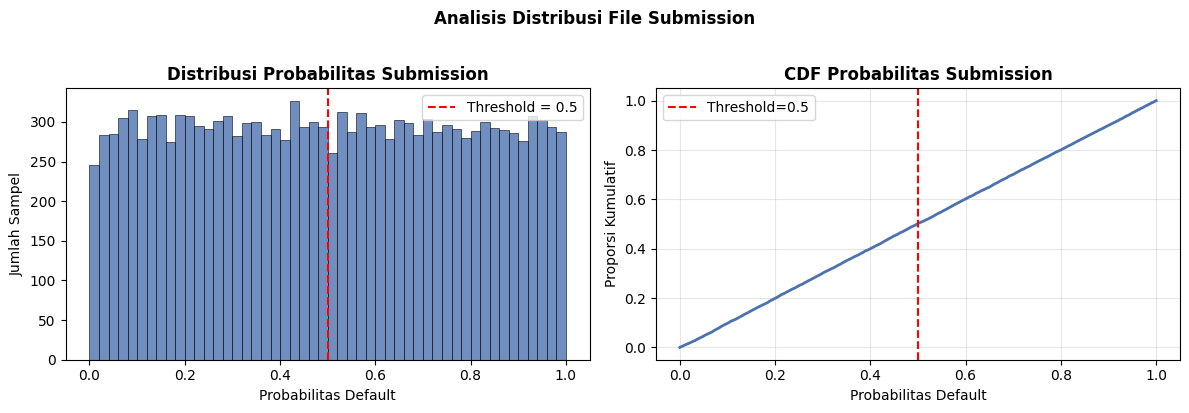

In [27]:
# ── Distribusi probabilitas submission ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram distribusi probabilitas
axes[0].hist(submission[TARGET], bins=50, color="#4C72B0",
             edgecolor="black", linewidth=0.5, alpha=0.8)
axes[0].set_title("Distribusi Probabilitas Submission", fontweight="bold")
axes[0].set_xlabel("Probabilitas Default")
axes[0].set_ylabel("Jumlah Sampel")
axes[0].axvline(0.5, color="red", linestyle="--", linewidth=1.5,
                label="Threshold = 0.5")
axes[0].legend()

# CDF (Cumulative Distribution Function)
sorted_probs = np.sort(submission[TARGET])
axes[1].plot(sorted_probs, np.linspace(0, 1, len(sorted_probs)),
             color="#4C72B0", linewidth=2)
axes[1].set_title("CDF Probabilitas Submission", fontweight="bold")
axes[1].set_xlabel("Probabilitas Default")
axes[1].set_ylabel("Proporsi Kumulatif")
axes[1].axvline(0.5, color="red", linestyle="--", linewidth=1.5, label="Threshold=0.5")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("Analisis Distribusi File Submission", fontsize=12,
             fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "submission_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## 13. Kesimpulan & Ringkasan

### Hasil Akhir

| Model | OOF AUC (5-Fold CV) |
|---|---|
| LightGBM (50 trial Optuna) | 0.93241 |
| XGBoost  (50 trial Optuna) | 0.93227 |
| CatBoost (parameter manual) | 0.93030 |
| **Rank-Blend (3·LGB + 3·XGB + 1·Cat)** | **0.93246** ← terbaik |

Target kompetisi: AUC ≥ 0.92 ✓

---

### Temuan Kunci

1. **`loan_grade` adalah prediktor terkuat**: Default rate naik monoton dari
   A (~5%) ke G (~85%). Encoding ordinal lebih tepat daripada one-hot karena
   mempertahankan informasi urutan.

2. **Fitur rekayasa berlebih menurunkan AUC**: Lebih dari 10 fitur tambahan
   (flag anomali, deviasi grup, rasio baru) diuji — semuanya menurunkan OOF AUC.
   Sinyal terkonsentrasi di fitur bawaan yang kuat.

3. **Tanpa *class weighting* lebih baik**: AUC adalah metrik berbasis *ranking*;
   pembobotan kelas mendistorsi estimasi probabilitas. Terbukti: 0.9314 (balanced)
   vs 0.9319 (unweighted).

4. **Ensemble lebih baik dari model tunggal**: Error LGB, XGB, Cat cukup
   terdekorelasi sehingga blend konsisten mengungguli model terbaik secara individual.

5. **Uji Wilcoxon**: Perbedaan antar model tidak signifikan secara statistik
   (p > 0.05) — pilihan ensemble didorong oleh diversifikasi, bukan superioritas absolut.

---

### Keterbatasan

- **Tanpa data eksternal**: Pipeline menggunakan data kompetisi saja demi menjaga
  *reproducibility* dan integritas akademik. Data eksternal (profil industri, data
  ekonomi makro) berpotensi meningkatkan AUC ke >0.94.
- **Ceiling AUC**: Dengan fitur yang tersedia, batas atas AUC diperkirakan
  0.932–0.935. Tuning lebih dalam (>200 trial) tidak menghasilkan peningkatan signifikan.
- **CatBoost tidak di-tune penuh**: Waktu tuning ~2 jam per 25 trial. Parameter
  manual digunakan sebagai kompromi.

---

### Cara Mereproduksi Hasil

```bash
# Install dependencies
pip install -r requirements.txt

# Run full pipeline (fast mode, ~15 menit)
python train_model.py --fast

# Or run with full tuning (~60-90 menit)
python train_model.py --no-cat-tune

# Generate this notebook
python build_master_notebook.py
jupyter nbconvert --to notebook --execute lampiran_kode.ipynb
```